In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
plt.style.use("fast")
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
from plotly.subplots import make_subplots
import plotly.graph_objs as go

import random
import statistics

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from itertools import combinations
from collections import Counter
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from tqdm.notebook import tqdm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import category_encoders as ce
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn import metrics

In [2]:
df_train = pd.read_csv('/Users/huynhphuongchi/Desktop/Unipi/Data Mining/Project/train_clean_reg.csv', skipinitialspace=True)
df_test = pd.read_csv('/Users/huynhphuongchi/Desktop/Unipi/Data Mining/Project/test_clean_reg.csv', skipinitialspace=True)

train_reg = pd.read_csv('/Users/huynhphuongchi/Desktop/Unipi/Data Mining/Project/dm1_2425_imdb_rating/train_reg.csv')
test_reg = pd.read_csv('/Users/huynhphuongchi/Desktop/Unipi/Data Mining/Project/dm1_2425_imdb_rating/test_reg.csv')

In [3]:
train = pd.concat([train_reg["averageRating"], df_train.drop(columns=['rating'])], axis=1)
test = pd.concat([test_reg["averageRating"], df_test.drop(columns=['rating'])], axis=1)

In [4]:
train.head()

,averageRating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,titleType,awardNominationsExcludeWins,canHaveEpisodes,isAdult,numRegions,userReviewsTotal,countryOfOrigin,genres
0,7.5,1995,40.0,0,779,1,0,21,1,tvEpisode,0,False,False,1,0,['US'],"Action,Adventure,Animation"
1,5.9,1982,28.0,0,11,1,0,1,0,videoGame,0,False,False,1,0,['XWG'],Action
2,5.7,1992,90.0,0,38,1,0,24,0,movie,0,False,False,1,1,['RU'],Comedy
3,5.7,2021,31.0,0,15,22,0,56,0,tvSeries,0,True,False,1,0,['MX'],Reality-TV
4,8.0,2020,80.0,1,15718,347,2,47,4,tvSeries,1,True,False,32,452,['KR'],"Comedy,Drama,Romance"


# Pre-processing

### Checking missing value

In [5]:
def missing_values(data : pd.DataFrame, threshold : float = 10):
    na_count = data.isna().sum()
    na_exist = na_count[na_count > 0]
    na_abs_frq = na_exist.values
    na_rel_frq = round(na_exist/len(data)*100)
    missings = pd.DataFrame({'Nº of missings': na_abs_frq, '% of missings': na_rel_frq})
    missings = missings.sort_values(by = 'Nº of missings', ascending = False)
    if threshold: missings['Above threshold'] = [True if x > threshold else False for x in missings['% of missings']]
    return missings

In [6]:
missing_values(train)

,Nº of missings,% of missings,Above threshold


In [7]:
missing_values(test)

,Nº of missings,% of missings,Above threshold


## Noise

In [8]:
conditions = ~(
    (train['runtimeMinutes'] > 1000) |
    (train['runtimeMinutes'] == 0) |
    (train['awardWins'] > 100) |
    (train['totalVideos'] > 150) |
    (train['totalCredits'] > 6000) |
    (train['userReviewsTotal'] > 2000) |
    (train['awardNominationsExcludeWins'] > 150)
)

train = train[conditions]

## Grouping

In [9]:
# Clean the 'countryOfOrigin' column
train['countryOfOrigin'] = train['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(', ')

# Count country frequency
country_counts = train['countryOfOrigin'].explode().value_counts()

# Identify top 10 countries
top_10_countries = country_counts.head(10).index.tolist()

def map_to_top10_countries(country_list, top_countries):
    # Replace non-top countries with 'Others'
    cleaned_list = [country if country in top_countries else 'Other Countries' for country in country_list]
    # Remove duplicates while maintaining order
    cleaned_list = list(dict.fromkeys(cleaned_list))
    # Move 'Others' to the end
    others = [c for c in cleaned_list if c == 'Other Countries']
    main_countries = [c for c in cleaned_list if c != 'Other Countries']
    return main_countries + others

# Clean 'countryOfOrigin' column and apply the function
train['countryOfOrigin'] = train['countryOfOrigin'].apply(lambda x: map_to_top10_countries(x, top_10_countries))

test['countryOfOrigin'] = test['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(', ')
test['countryOfOrigin'] = test['countryOfOrigin'].apply(lambda x: map_to_top10_countries(x, top_10_countries))

In [10]:
train['genres'] = train['genres'].str.split(',').apply(lambda x: [genre.strip() for genre in x] if isinstance(x, list) else [])
test['genres'] = test['genres'].str.split(',').apply(lambda x: [genre.strip() for genre in x] if isinstance(x, list) else [])

genre_groupings = {
    'Drama': ['Drama'],
    'Comedy': ['Comedy'],
    'Romance': ['Romance'],
    'Short': ['Short'],
    'Action-Adventure': ['Action', 'Adventure'],
    'Sci-Fi-Fantasy': ['Sci-Fi', 'Fantasy'],
    'Horror': ['Horror'],
    'Documentary': ['Documentary', 'Bibliography'],
    'Animation-Family': ['Animation', 'Family'],
    'Crime-Mystery': ['Crime', 'Mystery', 'Thriller'],
    'Reality-TV': ['Reality-TV', 'Game-Show', 'Talk-Show'],
    'Music-Musical': ['Music', 'Musical'],
    'News-Sports': ['News', 'Sport'],
    'War-History': ['War', 'History']
}

# Function to reassign genres to new groups
def reassign_genres(genres_list, groupings):
    grouped_genres = set()
    for genre in genres_list:
        added = False
        for group, genres in groupings.items():
            if genre in genres:
                grouped_genres.add(group)
                added = True
        if not added:
            grouped_genres.add('Other genre')
    return list(grouped_genres)

# Apply reassignment to train and test datasets
train['genres'] = train['genres'].apply(lambda x: reassign_genres(x, genre_groupings))
test['genres'] = test['genres'].apply(lambda x: reassign_genres(x, genre_groupings))

In [11]:
train.genres.value_counts()

genres
[Drama]                                    1776
[Comedy]                                   1378
[Documentary]                               869
[Crime-Mystery, Drama]                      819
[Other genre]                               496
                                           ... 
[War-History, Crime-Mystery, Horror]          1
[Documentary, Crime-Mystery, Horror]          1
[Comedy, Other genre, Animation-Family]       1
[Comedy, News-Sports, Music-Musical]          1
[Documentary, News-Sports, Drama]             1
Name: count, Length: 373, dtype: int64

## Encoding

In [12]:
def process_and_encode_data(df, columns_to_process, categorical_vars):

    # Step 1: Process columns (convert lists to comma-separated strings)
    for col in columns_to_process:
        df[col] = df[col].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
    
    # Step 2: Perform binary encoding
    encoder = ce.BinaryEncoder(cols=categorical_vars)
    df_encoded = encoder.fit_transform(df)
    
    # Step 3: Restore original column values using binary representation
    for col in categorical_vars:
        binary_cols = [col + '_' + str(i) for i in range(df_encoded.filter(like=col).shape[1])]
        df_encoded[col] = df_encoded[binary_cols].apply(
            lambda row: sum([bit * (2 ** idx) for idx, bit in enumerate(row)]), axis=1
        )
        df_encoded.drop(columns=binary_cols, inplace=True)
    
    return df_encoded

# Apply function to train and test datasets
columns_to_process = ['countryOfOrigin', 'genres', 'titleType']
categorical_vars = ['countryOfOrigin', 'genres', 'titleType']

# Assuming train and test are your datasets
train = process_and_encode_data(train, columns_to_process, categorical_vars)
test = process_and_encode_data(test, columns_to_process, categorical_vars)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:411: FutureWarning: The `_get_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:411: FutureWarning: The `_get_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


In [13]:
bool_vars = ['canHaveEpisodes', 'isAdult']
categorical = ['titleType', 'countryOfOrigin', 'genres']
numeric = [col for col in train.columns if col not in bool_vars + categorical]

norm = StandardScaler()
norm.fit(train[numeric])

train_norm = train.copy()
test_norm = test.copy()

train_norm[numeric] = norm.transform(train[numeric])
test_norm[numeric] = norm.transform(test[numeric])

In [14]:
train_norm.describe().T

,count,mean,std,min,25%,50%,75%,max
averageRating,16423.0,4.694804e-16,1.000030,-4.211280,-0.595028,0.142983,0.659590,2.430815
startYear,16423.0,5.145302e-16,1.000030,-4.358997,-0.530684,0.196696,0.809226,1.230340
runtimeMinutes,16423.0,6.424867e-17,1.000030,-1.457974,-0.744679,-0.209708,0.809284,13.801437
awardWins,16423.0,-4.056103e-18,1.000030,-0.169800,-0.169800,-0.169800,-0.169800,35.395078
numVotes,16423.0,1.946929e-18,1.000030,-0.073797,-0.073288,-0.072218,-0.066510,49.186452
totalImages,16423.0,-1.859047e-18,1.000030,-0.154103,-0.140546,-0.140546,-0.072761,47.349868
totalVideos,16423.0,-1.054587e-18,1.000030,-0.112764,-0.112764,-0.112764,-0.112764,62.016618
totalCredits,16423.0,3.125903e-17,1.000030,-0.501787,-0.368132,-0.217770,0.041186,41.039787
criticReviewsTotal,16423.0,9.829290e-18,1.000030,-0.181675,-0.181675,-0.181675,-0.115799,34.930117
awardNominationsExcludeWins,16423.0,7.084660e-18,1.000030,-0.149939,-0.149939,-0.149939,-0.149939,34.324784


In [15]:
train.select_dtypes(include='number').columns

Index(['averageRating', 'startYear', 'runtimeMinutes', 'awardWins', 'numVotes',
       'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal',
       'awardNominationsExcludeWins', 'numRegions', 'userReviewsTotal',
       'countryOfOrigin', 'genres', 'titleType'],
      dtype='object')

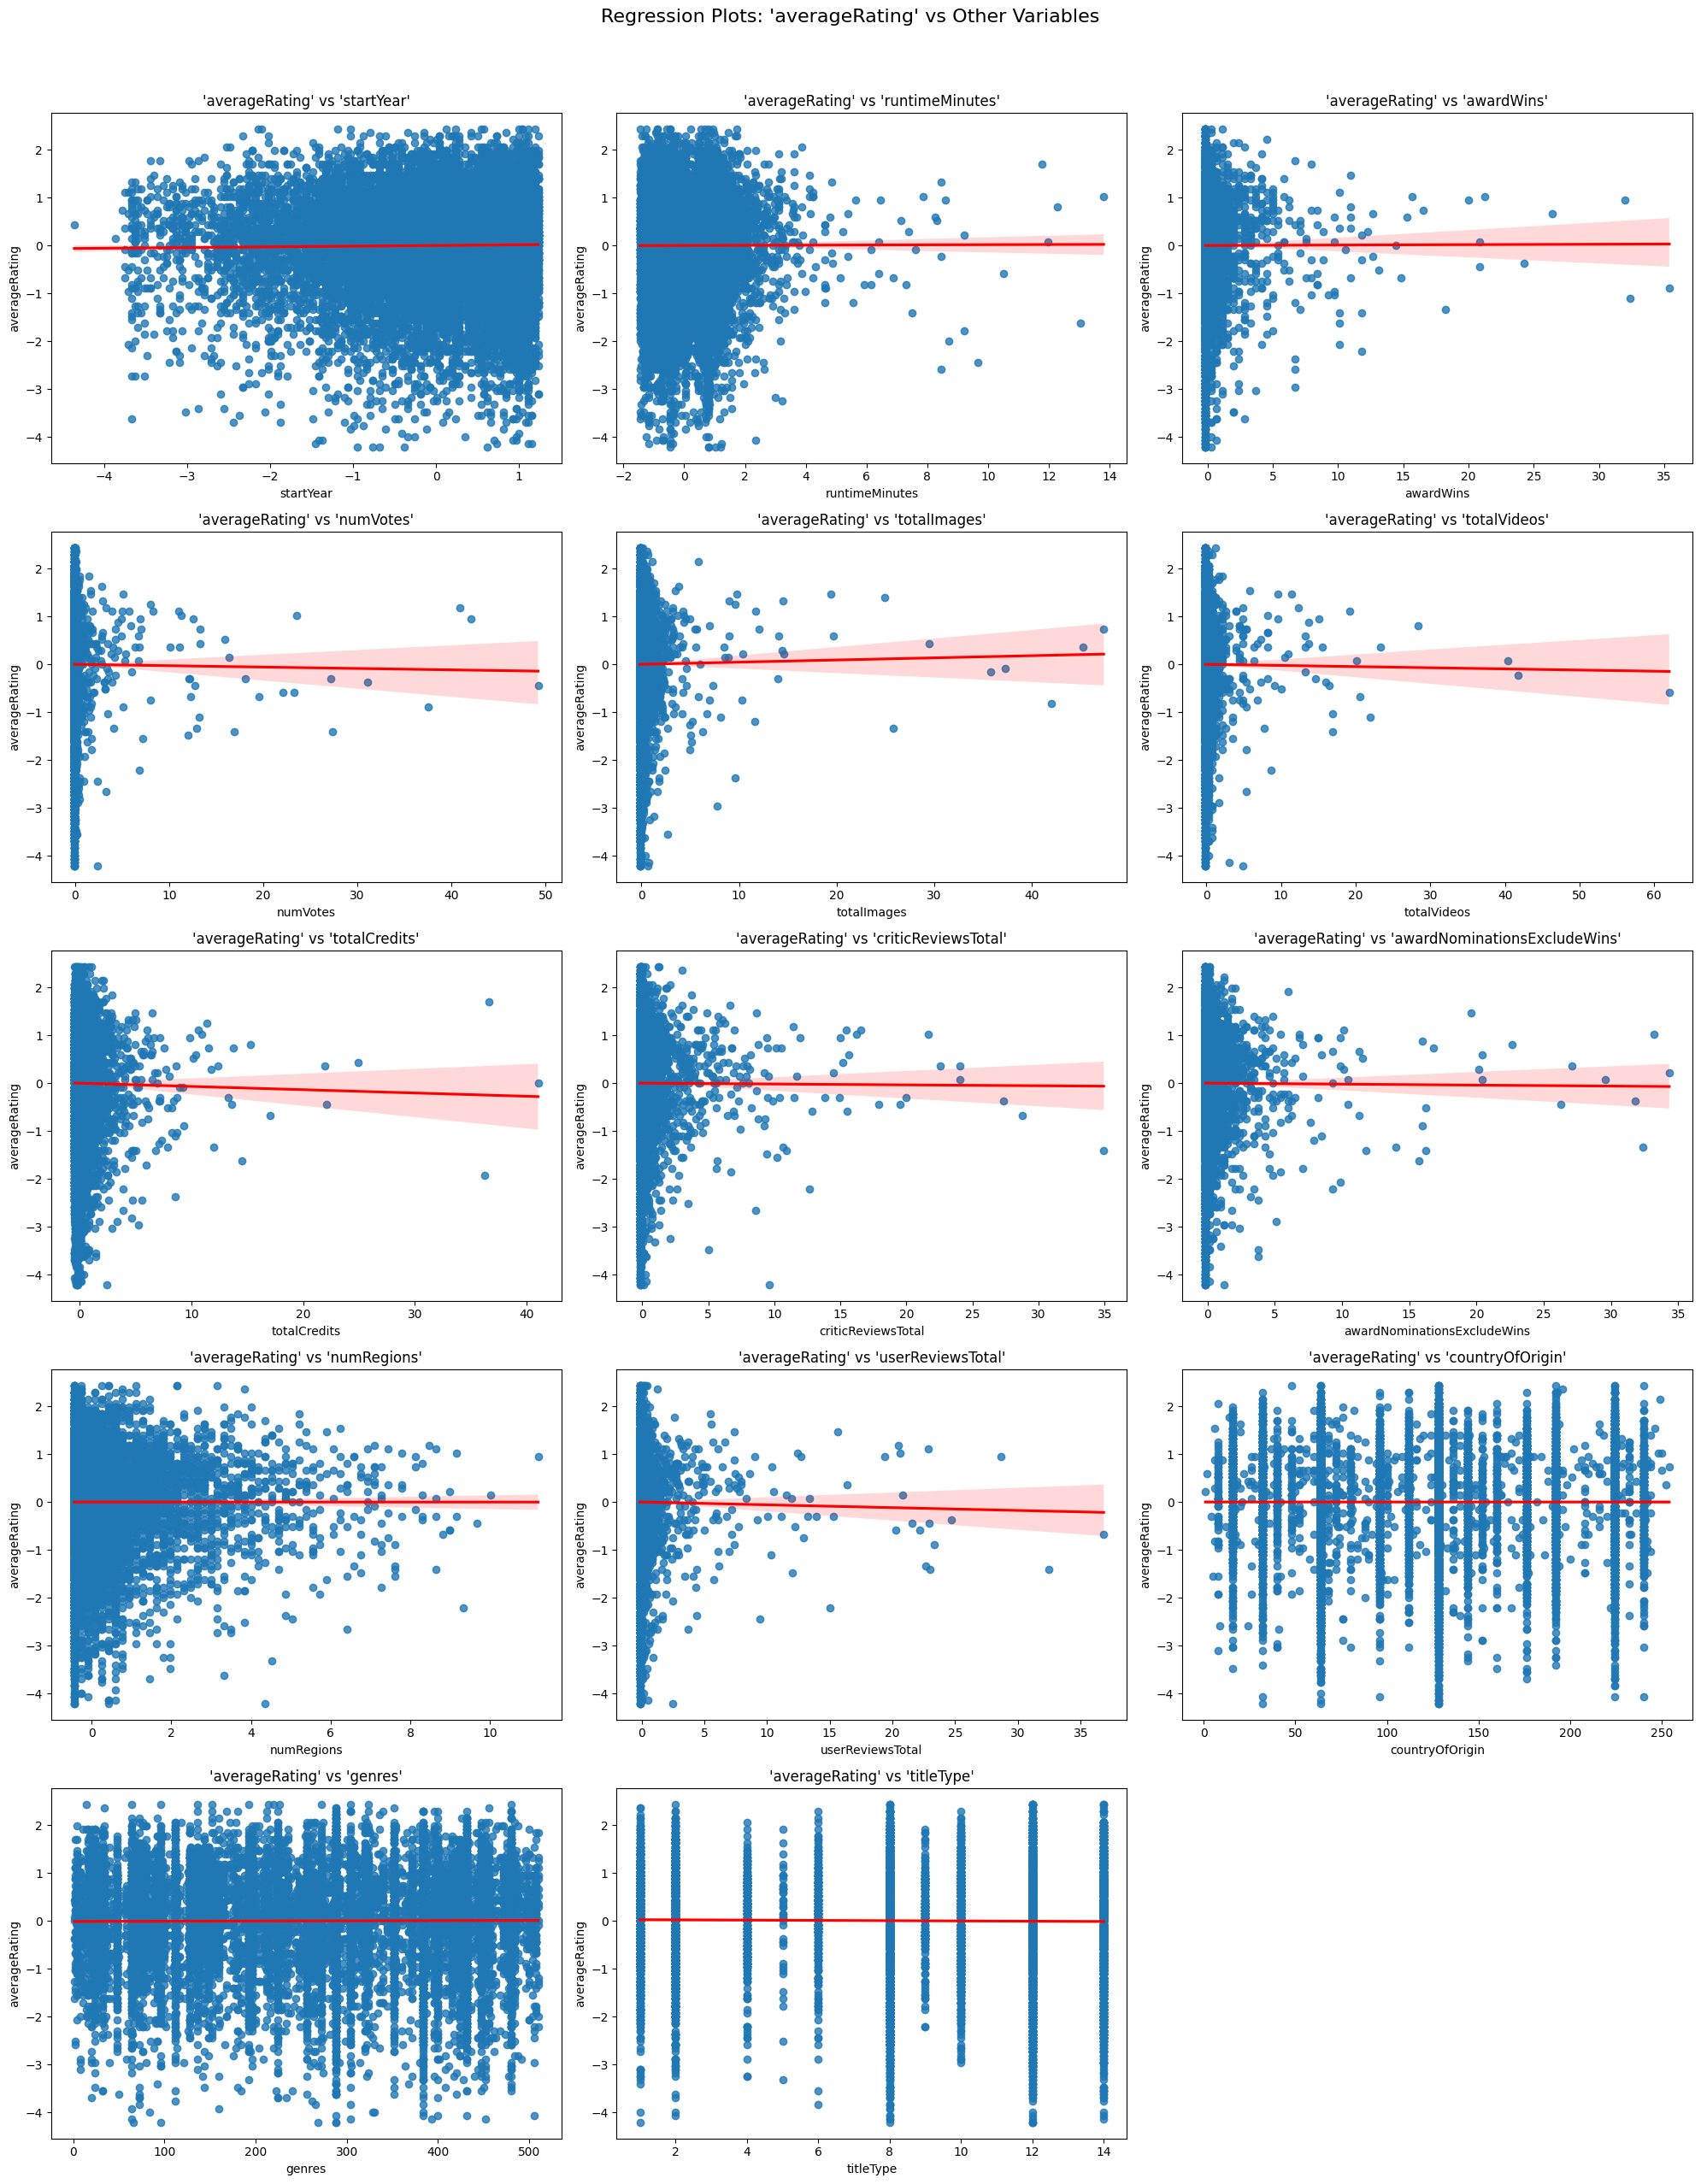

In [16]:
columns_to_plot = [col for col in train.select_dtypes(include='number').columns if col != 'averageRating']

n_cols = 3  # Số cột cố định
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols  # Tính số hàng

# Tạo các subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))  
axes = axes.flatten()  # Chuyển ma trận các trục thành mảng 1D

# Vẽ từng biểu đồ
for i, col in enumerate(columns_to_plot):
    sns.regplot(data=train_norm, x=col, y='averageRating', ax=axes[i], line_kws={'color': 'red'})
    axes[i].set_title(f"'averageRating' vs '{col}'")

# Xóa các trục dư
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])  # Loại bỏ trục thừa

# Tùy chỉnh tiêu đề và hiển thị
fig.suptitle("Regression Plots: 'averageRating' vs Other Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Calculate correlation of 'averageRating' with other variables
correlation_with_averageRating = train.corr(numeric_only=True, method='spearman')['averageRating']

# Sort correlations by value
sorted_corr = correlation_with_averageRating.sort_values(ascending=False)

# Convert to DataFrame for display
sorted_correlation_df = sorted_corr.to_frame(name='Correlation').reset_index()
sorted_correlation_df.columns = ['Variable', 'Correlation']

# Display as styled DataFrame
styled_correlation_df = sorted_correlation_df.style.background_gradient(cmap='PuOr', vmin=-1, vmax=1)
styled_correlation_df

,Variable,Correlation
0,averageRating,1.000000
1,awardNominationsExcludeWins,0.012961
2,startYear,0.011551
3,awardWins,0.010596
4,genres,0.009758
5,isAdult,0.007650
6,criticReviewsTotal,0.004565
7,canHaveEpisodes,0.002839
8,userReviewsTotal,0.002065
9,runtimeMinutes,0.001951


# Univariate

## Simple Regression

### Linear

In [18]:
predictors = ['awardNominationsExcludeWins', 'startYear', 'awardWins','genres','isAdult','titleType']
target = ["averageRating"]

In [19]:
results = []

# Perform univariate regression and store detailed metrics
for predictor in predictors:
    # Prepare the data
    X_train = train_norm[[predictor]]
    y_train = train[target]
    X_test = test_norm[[predictor]]
    y_test = test[target]
    
    # Fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    coef = model.coef_[0][0]
    intercept = model.intercept_[0]
    
    # Append the results
    results.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Intercept': intercept,
        'R²': r2,
        'MSE': mse,
        'MAE': mae
    })
results_df = pd.DataFrame(results)
results_df

,Predictor,Coefficient,Intercept,R²,MSE,MAE
0,awardNominationsExcludeWins,-0.002769,6.706260,-0.000065,1.832282,1.062450
1,startYear,0.019643,6.706260,0.000209,1.831780,1.062314
2,awardWins,0.001163,6.706260,-0.000004,1.832170,1.062362
3,genres,0.000056,6.690523,0.000318,1.831580,1.062340
4,isAdult,0.070692,6.704426,-0.000132,1.832404,1.062392
5,titleType,-0.003801,6.741948,0.000027,1.832114,1.061331


In [20]:
alpha = 1.0  # Giá trị mặc định, bạn có thể điều chỉnh dựa trên kết quả

ridge_results = []

for predictor in predictors:
    X_train = train_norm[[predictor]]
    y_train = train[target]
    X_test = test_norm[[predictor]]
    y_test = test[target]
    
    model = Ridge(alpha=alpha)  
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    coef = model.coef_[0]
    intercept = model.intercept_ 
    
    ridge_results.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Intercept': intercept,
        'R²': r2,
        'MSE': mse,
        'MAE': mae
    })

ridge_results_df = pd.DataFrame(ridge_results)
ridge_results_df

,Predictor,Coefficient,Intercept,R²,MSE,MAE
0,awardNominationsExcludeWins,-0.002768,[6.706259514096084],-0.000065,1.832282,1.062450
1,startYear,0.019642,[6.706259514096084],0.000209,1.831780,1.062314
2,awardWins,0.001163,[6.706259514096084],-0.000004,1.832170,1.062362
3,genres,0.000056,[6.690523468776089],0.000318,1.831580,1.062340
4,isAdult,0.070522,[6.704430238268986],-0.000131,1.832404,1.062392
5,titleType,-0.003801,[6.741948132134243],0.000027,1.832114,1.061331


In [21]:
alpha = 1.0  # Giá trị mặc định, bạn có thể điều chỉnh dựa trên kết quả

# Danh sách lưu kết quả
lasso_results = []

for predictor in predictors:
    # Chuẩn bị dữ liệu
    X_train = train_norm[[predictor]]
    y_train = train[target]
    X_test = test_norm[[predictor]]
    y_test = test[target]
    
    # Ridge hoặc Lasso Regression
    # Để thay đổi giữa Ridge và Lasso, chỉ cần đổi Ridge() thành Lasso()
    model = Lasso(alpha=alpha)  # Hoặc model = Ridge(alpha=alpha)
    
    # Huấn luyện mô hình
    model.fit(X_train, y_train)
    
    # Dự đoán trên tập test
    y_pred = model.predict(X_test)
    
    # Đánh giá mô hình
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    coef = model.coef_[0] 
    intercept = model.intercept_
    
    # Ghi lại kết quả
    lasso_results.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Intercept': intercept,
        'R²': r2,
        'MSE': mse,
        'MAE': mae
    })

# Biểu diễn kết quả thành DataFrame
lasso_results_df = pd.DataFrame(lasso_results)
lasso_results_df

,Predictor,Coefficient,Intercept,R²,MSE,MAE
0,awardNominationsExcludeWins,-0.000000,[6.706259514096084],-0.000025,1.832208,1.062399
1,startYear,0.000000,[6.706259514096084],-0.000025,1.832208,1.062399
2,awardWins,0.000000,[6.706259514096084],-0.000025,1.832208,1.062399
3,genres,0.000005,[6.7047402474749855],0.000012,1.832142,1.062387
4,isAdult,0.000000,[6.706259514096084],-0.000025,1.832208,1.062399
5,titleType,-0.000000,[6.706259514096084],-0.000025,1.832208,1.062399


### Non-linear

In [22]:
from sklearn.tree import DecisionTreeRegressor
# Initialize results list for Decision Tree regression
tree_results = []

# Perform univariate Decision Tree regression for each predictor
for predictor in predictors:
    # Prepare the data
    X_train = train[[predictor]]
    y_train = train[target]
    X_test = test[[predictor]]
    y_test = test[target]
    
    # Fit the Decision Tree regression model
    tree_model = DecisionTreeRegressor(max_depth=9, min_samples_leaf=100,min_samples_split=5)
    tree_model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = tree_model.predict(X_test)
    
    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Append the results
    tree_results.append({
        'Predictor': predictor,
        'R²': r2,
        'MSE': mse,
        'MAE': mae
    })

# Convert Decision Tree results to DataFrame for display
tree_results_df = pd.DataFrame(tree_results)
tree_results_df

,Predictor,R²,MSE,MAE
0,awardNominationsExcludeWins,-0.001396,1.834721,1.063503
1,startYear,-0.005988,1.843134,1.066591
2,awardWins,-0.000388,1.832874,1.062750
3,genres,-0.008219,1.847221,1.066428
4,isAdult,-0.000132,1.832404,1.062392
5,titleType,-0.001334,1.834607,1.062611


In [23]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize results list for KNN regression
knn_results = []

# Perform univariate KNN regression for each predictor
for predictor in predictors:
    # Prepare the data
    X_train = train_norm[[predictor]]
    y_train = train[target]
    X_test = test_norm[[predictor]]
    y_test = test[target]
    
    # Fit the KNN regression model
    knn_model = KNeighborsRegressor(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = knn_model.predict(X_test)
    
    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Append the results
    knn_results.append({
        'Predictor': predictor,
        'R²': r2,
        'MSE': mse,
        'MAE': mae
    })

# Convert KNN results to DataFrame for display
knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,Predictor,R²,MSE,MAE
0,awardNominationsExcludeWins,-0.392280,2.550884,1.322380
1,startYear,-0.222101,2.239088,1.165458
2,awardWins,-0.407874,2.579455,1.335674
3,genres,-0.288594,2.360913,1.237882
4,isAdult,-0.010774,1.851903,1.081471
5,titleType,-0.107596,2.029296,1.113231


## Multiple Regression

### Linear

In [24]:
X_train1 = train_norm[predictors].values
y_train1 = train[target].values

X_test1 = test_norm[predictors].values
y_test1 = test[target].values

In [25]:
lireg = LinearRegression()
lireg.fit(X_train1, y_train1)

LinearRegression()

In [26]:
y_pred = lireg.predict(X_test1)
print('R2: %.3f' % r2_score(y_test1, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test1, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test1, y_pred))

R2: 0.000
MSE: 1.831
MAE: 1.061


In [27]:
lasso = Lasso()
lasso.fit(X_train1, y_train1)

y_pred_la = lasso.predict(X_test1)
print('R2: %.3f' % r2_score(y_test1, y_pred_la))
print('MSE: %.3f' % mean_squared_error(y_test1, y_pred_la))
print('MAE: %.3f' % mean_absolute_error(y_test1, y_pred_la))

R2: 0.000
MSE: 1.832
MAE: 1.062


In [28]:
rid = Ridge()
rid.fit(X_train1, y_train1)

y_pred_rid = rid.predict(X_test1)
print('R2: %.3f' % r2_score(y_test1, y_pred_rid))
print('MSE: %.3f' % mean_squared_error(y_test1, y_pred_rid))
print('MAE: %.3f' % mean_absolute_error(y_test1, y_pred_rid))

R2: 0.000
MSE: 1.831
MAE: 1.061


### Non-linear

In [29]:
X_train2 = train[predictors].values
X_test2 = test[predictors].values

In [30]:
tree = DecisionTreeRegressor()
tree.fit(X_train2, y_train1)

y_pred_tree = tree.predict(X_test2)
print('R2: %.3f' % r2_score(y_test1, y_pred_tree))
print('MSE: %.3f' % mean_squared_error(y_test1, y_pred_tree))
print('MAE: %.3f' % mean_absolute_error(y_test1, y_pred_tree))

R2: -0.926
MSE: 3.530
MAE: 1.484


In [31]:
knn = KNeighborsRegressor()
knn.fit(X_train1, y_train1)

y_pred_knn = knn.predict(X_test1)
print('R2: %.3f' % r2_score(y_test1, y_pred_knn))
print('MSE: %.3f' % mean_squared_error(y_test1, y_pred_knn))
print('MAE: %.3f' % mean_absolute_error(y_test1, y_pred_knn))

R2: -0.200
MSE: 2.198
MAE: 1.178


# Multivariate

## Linear

In [32]:
X_train_mul = train_norm.drop(columns=['averageRating']).values
y_train_mul = train[['averageRating', 'runtimeMinutes']].values

X_test_mul = test_norm.drop(columns=['averageRating']).values
y_test_mul = test[['averageRating', 'runtimeMinutes']].values

In [33]:
lireg = LinearRegression()
lireg.fit(X_train_mul, y_train_mul)
y_pred = lireg.predict(X_test_mul)
print('R2: %.3f' % r2_score(y_test_mul, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test_mul, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test_mul, y_pred))

R2: 0.500
MSE: 0.916
MAE: 0.531


In [34]:
lasso_mul = Lasso()
lasso_mul.fit(X_train_mul, y_train_mul)
y_pred = lasso_mul.predict(X_test_mul)
print('R2: %.3f' % r2_score(y_test_mul, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test_mul, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test_mul, y_pred))

R2: 0.500
MSE: 1.549
MAE: 0.955


In [35]:
rid_mul = Ridge()
rid_mul.fit(X_train_mul, y_train_mul)
y_predridmul = rid_mul.predict(X_test_mul)
print('R2: %.3f' % r2_score(y_test_mul, y_predridmul))
print('MSE: %.3f' % mean_squared_error(y_test_mul, y_predridmul))
print('MAE: %.3f' % mean_absolute_error(y_test_mul, y_predridmul))

R2: 0.500
MSE: 0.916
MAE: 0.532


## Non-linear

In [36]:
X_train3 = train.drop(columns=['averageRating']).values
X_test3 = test.drop(columns=['averageRating']).values

In [37]:
tree_mul = DecisionTreeRegressor()
tree_mul.fit(X_train3, y_train_mul)

y_predtreemul = lasso_mul.predict(X_test3)
print('R2: %.3f' % r2_score(y_test_mul, y_predtreemul))
print('MSE: %.3f' % mean_squared_error(y_test_mul, y_predtreemul))
print('MAE: %.3f' % mean_absolute_error(y_test_mul, y_predtreemul))

R2: -2135.012
MSE: 3830251.274
MAE: 1138.284


In [38]:
knn = KNeighborsRegressor()
knn.fit(X_train_mul, y_train_mul)

y_pred_knnmul = knn.predict(X_test_mul)
print('R2: %.3f' % r2_score(y_test_mul, y_pred_knnmul))
print('MSE: %.3f' % mean_squared_error(y_test_mul, y_pred_knnmul))
print('MAE: %.3f' % mean_absolute_error(y_test_mul, y_pred_knnmul))

R2: -0.137
MSE: 943.430
MAE: 16.723
